In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import waterfall_chart

from fastai.imports import *
from fastai.tabular import *
from pandas_summary import DataFrameSummary
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from IPython.display import display

from sklearn import metrics
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_recall_curve, confusion_matrix, recall_score, precision_score
from sklearn.model_selection import cross_val_score
from matplotlib.ticker import FuncFormatter

In [2]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [3]:
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score, brier_score_loss
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import matplotlib.pyplot as plt

file_name = "final_df.csv"
df = pd.read_csv(file_name)
df.dropna(inplace=True)
df['PDI'] = df['PDI'].astype(int)
df['PDI_complete'] = df['PDI_complete'].astype(int)

In [4]:
df_with_tracking = df[["R","theta","shooting_angle","assist_type_through_pass","assist_type_long_pass",
                       "shot_bodyPart_head_or_other","direct_free_kick","PDI","PDI_complete","gk_line_offset","shot_isGoal"]]
y = df_with_tracking["shot_isGoal"]
X = df_with_tracking.drop(columns="shot_isGoal")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=80,stratify=y)

=== Attempt 1: Basic XGBoost Classifier ===
Optimal threshold for balanced accuracy: 0.100
Best balanced accuracy: 0.6677

=== Cross Validation ===
CV Results (last 5 rounds):
    train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
21        0.750442       0.015521       0.714032      0.031501
22        0.750859       0.015420       0.714275      0.031591
23        0.750868       0.015416       0.714289      0.031608
24        0.751570       0.015378       0.714495      0.030730
25        0.750989       0.015464       0.714815      0.030973

=== Grid Search for Hyperparameter Tuning (Balanced Accuracy) ===
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.5}
Best Balanced Accuracy score: 0.5925037177556195

=== Final Model with Best Parameters ===
Final model optimal threshold: 0.320
Final model best balanced accuracy: 0.7686

=== Comprehensive M

<Figure size 1000x800 with 0 Axes>

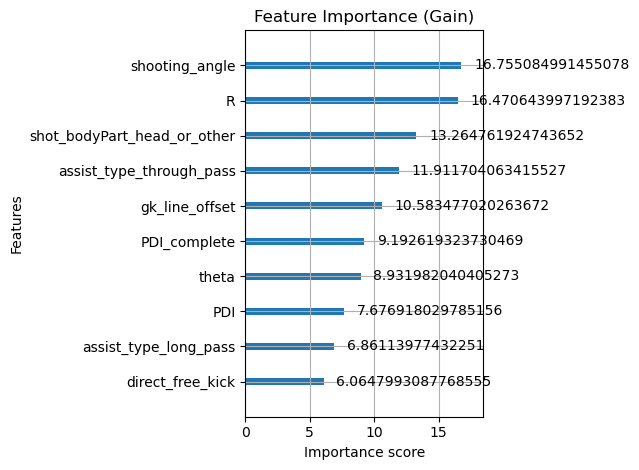

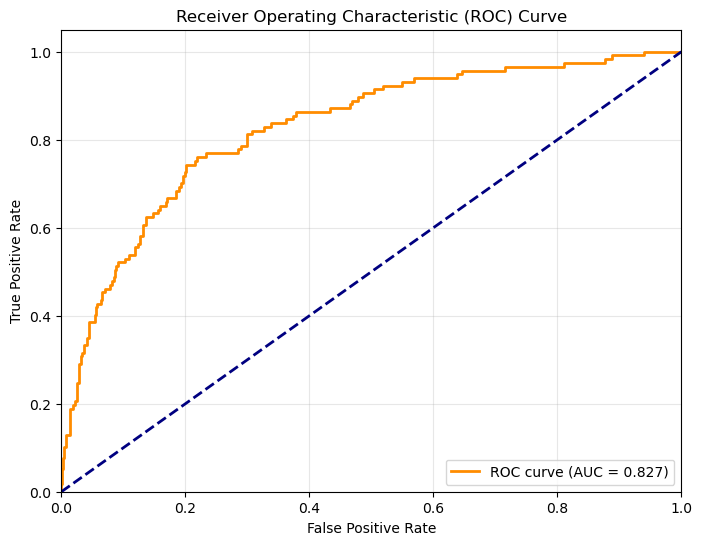

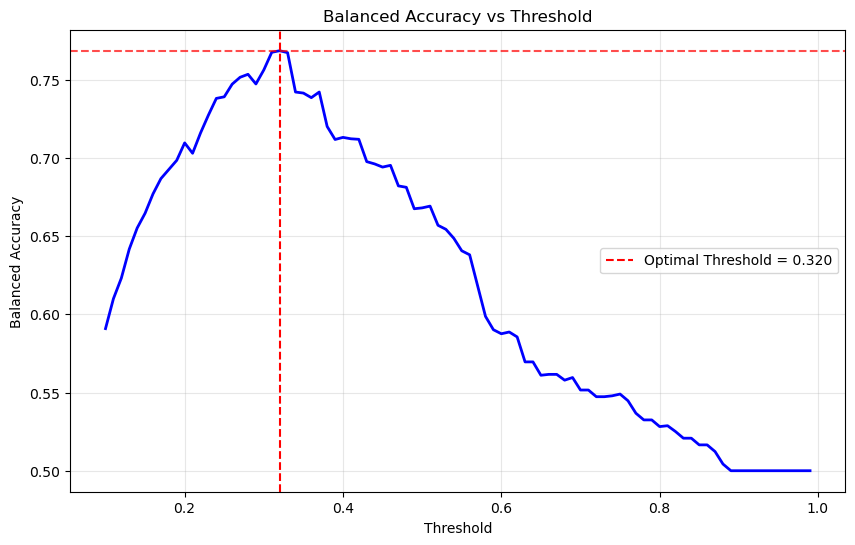


=== FINAL SUMMARY ===
Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.5}
Cross-validation Balanced Accuracy: 0.5925
Test set AUC: 0.8266
Optimal threshold: 0.320
Test set Balanced Accuracy (optimal threshold): 0.7686
Test set Accuracy (optimal threshold): 0.7813


In [5]:
# XGBoost Classification for Shot Goal Prediction - Optimized for Balanced Accuracy
import xgboost as xgb
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, recall_score, precision_score, 
                           f1_score, log_loss, roc_curve)
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_tnr(y_true, y_pred):
    """Calculate True Negative Rate (Specificity)"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

def evaluate_model_at_threshold(y_true, y_pred_proba, threshold=0.5):
    """Evaluate model at a specific threshold and return all metrics"""
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    metrics = {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_Acc': balanced_accuracy_score(y_true, y_pred),
        'TNR': calculate_tnr(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_pred_proba),
        'LogLoss': log_loss(y_true, y_pred_proba)
    }
    return metrics

def find_optimal_threshold(y_true, y_pred_proba, metric='balanced_accuracy'):
    """Find optimal threshold based on specified metric"""
    thresholds = np.arange(0.1, 1.0, 0.01)
    best_score = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        if metric == 'balanced_accuracy':
            score = balanced_accuracy_score(y_true, y_pred)
        elif metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif metric == 'accuracy':
            score = accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

# Create DMatrix for Cross Validation
data_dmatrix = xgb.DMatrix(data=X, label=y)

# Basic XGBoost Classifier - Attempt 1
print("=== Attempt 1: Basic XGBoost Classifier ===")
xg_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=20,
    random_state=42
)

xg_clf.fit(X_train, y_train)

# Get prediction probabilities
preds_train_proba = xg_clf.predict_proba(X_train)[:, 1]
preds_test_proba = xg_clf.predict_proba(X_test)[:, 1]

# Find optimal threshold for balanced accuracy
optimal_threshold, optimal_score = find_optimal_threshold(y_test, preds_test_proba, 'balanced_accuracy')
print(f"Optimal threshold for balanced accuracy: {optimal_threshold:.3f}")
print(f"Best balanced accuracy: {optimal_score:.4f}")

# Cross Validation with specific parameters
print("\n=== Cross Validation ===")
params = {
    'objective': 'binary:logistic',
    'colsample_bytree': 0.3,
    'learning_rate': 0.1,
    'max_depth': 5,
    'alpha': 10,
    'eval_metric': 'auc'
}

cv_results = xgb.cv(
    dtrain=data_dmatrix,
    params=params,
    nfold=3,
    num_boost_round=200,
    early_stopping_rounds=5,
    metrics="auc",
    as_pandas=True,
    seed=123
)

print("CV Results (last 5 rounds):")
print(cv_results.tail())

# Grid Search for hyperparameter tuning - OPTIMIZED FOR BALANCED ACCURACY
print("\n=== Grid Search for Hyperparameter Tuning (Balanced Accuracy) ===")
gbm_param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.3, 0.5, 0.7],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [1, 2, 3]  # Added to handle class imbalance
}

gbm = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42
)

# Use BALANCED ACCURACY as scoring metric
grid_search = GridSearchCV(
    estimator=gbm,
    param_grid=gbm_param_grid,
    scoring='balanced_accuracy',  # Changed to balanced_accuracy
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)

print('Best parameters found:', grid_search.best_params_)
print('Best Balanced Accuracy score:', grid_search.best_score_)

# Train final model with best parameters
print("\n=== Final Model with Best Parameters ===")
best_model = grid_search.best_estimator_
final_preds_proba = best_model.predict_proba(X_test)[:, 1]

# Find optimal threshold for the best model
final_optimal_threshold, final_optimal_score = find_optimal_threshold(y_test, final_preds_proba, 'balanced_accuracy')

print(f"Final model optimal threshold: {final_optimal_threshold:.3f}")
print(f"Final model best balanced accuracy: {final_optimal_score:.4f}")

# Create comprehensive metrics table
print("\n=== Comprehensive Metrics Table ===")

# Test different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, final_optimal_threshold]
metrics_data = []

for threshold in thresholds_to_test:
    metrics = evaluate_model_at_threshold(y_test, final_preds_proba, threshold)
    metrics['Model'] = f'XGBoost_Best'
    metrics_data.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df[['Model', 'Threshold', 'Accuracy', 'Balanced_Acc', 'TNR', 'Recall', 'F1', 'AUC', 'LogLoss']]

# Round values for better display
for col in ['Threshold', 'Accuracy', 'Balanced_Acc', 'TNR', 'Recall', 'F1', 'AUC', 'LogLoss']:
    metrics_df[col] = metrics_df[col].round(4)

print(metrics_df.to_string(index=False))

# Highlight the best balanced accuracy
best_balanced_acc_idx = metrics_df['Balanced_Acc'].idxmax()
print(f"\nBest Balanced Accuracy: {metrics_df.loc[best_balanced_acc_idx, 'Balanced_Acc']:.4f} at threshold {metrics_df.loc[best_balanced_acc_idx, 'Threshold']:.3f}")

# Classification Report at optimal threshold
final_preds_optimal = (final_preds_proba >= final_optimal_threshold).astype(int)
print("\n=== Classification Report (Optimal Threshold) ===")
print(classification_report(y_test, final_preds_optimal))

# Confusion Matrix
print("\n=== Confusion Matrix (Optimal Threshold) ===")
cm = confusion_matrix(y_test, final_preds_optimal)
print(cm)

# Feature Importance Plot
print("\n=== Feature Importance ===")
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type="gain", max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.tight_layout()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, final_preds_proba)
final_auc = roc_auc_score(y_test, final_preds_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Plot Balanced Accuracy vs Threshold
thresholds_range = np.arange(0.1, 1.0, 0.01)
balanced_acc_scores = []

for thresh in thresholds_range:
    y_pred = (final_preds_proba >= thresh).astype(int)
    balanced_acc_scores.append(balanced_accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(thresholds_range, balanced_acc_scores, 'b-', linewidth=2)
plt.axvline(x=final_optimal_threshold, color='red', linestyle='--', 
            label=f'Optimal Threshold = {final_optimal_threshold:.3f}')
plt.axhline(y=final_optimal_score, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Threshold')
plt.ylabel('Balanced Accuracy')
plt.title('Balanced Accuracy vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary
print("\n=== FINAL SUMMARY ===")
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Cross-validation Balanced Accuracy: {grid_search.best_score_:.4f}")
print(f"Test set AUC: {final_auc:.4f}")
print(f"Optimal threshold: {final_optimal_threshold:.3f}")
print(f"Test set Balanced Accuracy (optimal threshold): {final_optimal_score:.4f}")
print(f"Test set Accuracy (optimal threshold): {accuracy_score(y_test, final_preds_optimal):.4f}")


In [6]:
# Model Comparison: xgboost_goals vs shot_xg
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                           confusion_matrix, roc_auc_score, recall_score, 
                           f1_score, log_loss, brier_score_loss)

def calculate_tnr(y_true, y_pred):
    """Calculate True Negative Rate (Specificity)"""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

def find_optimal_threshold(y_true, y_pred_proba, metric='balanced_accuracy'):
    """Find optimal threshold based on specified metric"""
    thresholds = np.arange(0.1, 1.0, 0.01)
    best_score = 0
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        if metric == 'balanced_accuracy':
            score = balanced_accuracy_score(y_true, y_pred)
        elif metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif metric == 'accuracy':
            score = accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

def evaluate_model_at_threshold(y_true, y_pred_proba, threshold=0.5):
    """Evaluate model at a specific threshold and return all metrics"""
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    metrics = {
        'Threshold': threshold,
        'Balanced_Acc': balanced_accuracy_score(y_true, y_pred),
        'TNR': calculate_tnr(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_pred_proba),
        'LogLoss': log_loss(y_true, y_pred_proba),
        'Brier_Score': brier_score_loss(y_true, y_pred_proba)
    }
    return metrics

# Get predictions for test data
shot_xg_test_proba = df.loc[X_test.index, 'shot_xg'].values
shot_xg2_test_proba = df.loc[X_test.index, 'shot_xg2'].values

# Find optimal thresholds for all models
xgb_optimal_threshold, _ = find_optimal_threshold(y_test, final_preds_proba, 'balanced_accuracy')
shot_xg_optimal_threshold, _ = find_optimal_threshold(y_test, shot_xg_test_proba, 'balanced_accuracy')
shot_xg2_optimal_threshold, _ = find_optimal_threshold(y_test, shot_xg2_test_proba, 'balanced_accuracy')

# Evaluate all models at their optimal thresholds
comparison_data = []

# xgboost_goals model
xgb_metrics = evaluate_model_at_threshold(y_test, final_preds_proba, xgb_optimal_threshold)
xgb_metrics['Model'] = 'xgboost_goals'
comparison_data.append(xgb_metrics)

# shot_xg model
shot_xg_metrics = evaluate_model_at_threshold(y_test, shot_xg_test_proba, shot_xg_optimal_threshold)
shot_xg_metrics['Model'] = 'shot_xg'
comparison_data.append(shot_xg_metrics)

# shot_xg2 model
shot_xg2_metrics = evaluate_model_at_threshold(y_test, shot_xg2_test_proba, shot_xg2_optimal_threshold)
shot_xg2_metrics['Model'] = 'shot_xg2'
comparison_data.append(shot_xg2_metrics)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df[['Model', 'Threshold', 'Balanced_Acc', 'TNR', 'Recall', 'F1', 'AUC', 'Brier_Score', 'LogLoss']]

# Round values for better display (skip 'Model' column as it's text)
for col in ['Threshold', 'Balanced_Acc', 'TNR', 'Recall', 'F1', 'AUC', 'Brier_Score', 'LogLoss']:
    comparison_df[col] = comparison_df[col].round(4)

comparison_df

,Model,Threshold,Balanced_Acc,TNR,Recall,F1,AUC,Brier_Score,LogLoss
0,xgboost_goals,0.32,0.7686,0.7852,0.7521,0.4444,0.8266,0.1020,0.3500
1,shot_xg,0.19,0.7137,0.8290,0.5983,0.4130,0.7961,0.0886,0.2955
2,shot_xg2,0.16,0.6942,0.8414,0.5470,0.3975,0.7596,0.0883,0.3065


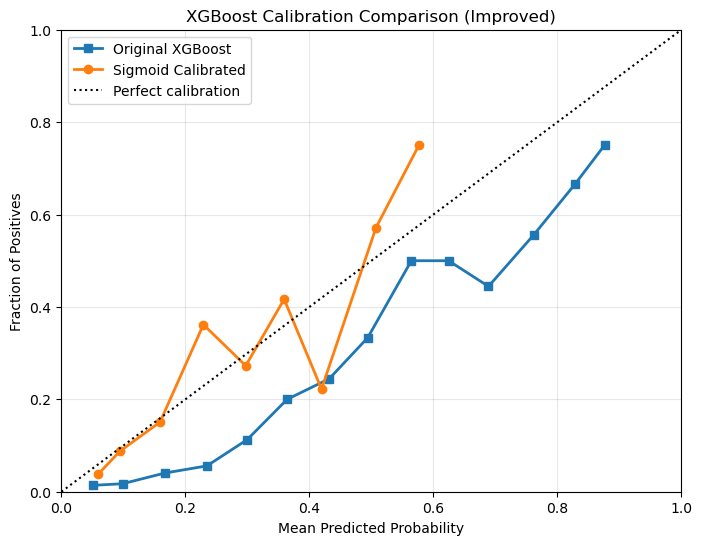

Original Brier Score: 0.1020
Sigmoid Calibrated Brier Score: 0.0939


In [11]:
# Improved XGBoost Model Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Try both calibration methods
cal_clf_sigmoid = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
cal_clf_isotonic = CalibratedClassifierCV(best_model, method='isotonic', cv=3)

cal_clf_sigmoid.fit(X_train, y_train)
cal_clf_isotonic.fit(X_train, y_train)

# Get predictions
sigmoid_preds_proba = cal_clf_sigmoid.predict_proba(X_test)[:, 1]
isotonic_preds_proba = cal_clf_isotonic.predict_proba(X_test)[:, 1]

# Calibration plot with more bins for smoother curves
fraction_pos, mean_pred = calibration_curve(y_test, final_preds_proba, n_bins=15)
fraction_pos_sig, mean_pred_sig = calibration_curve(y_test, sigmoid_preds_proba, n_bins=15)
fraction_pos_iso, mean_pred_iso = calibration_curve(y_test, isotonic_preds_proba, n_bins=15)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred, fraction_pos, "s-", label="Original XGBoost", linewidth=2)
plt.plot(mean_pred_sig, fraction_pos_sig, "o-", label="Sigmoid Calibrated", linewidth=2)
#plt.plot(mean_pred_iso, fraction_pos_iso, "^-", label="Isotonic Calibrated", linewidth=2)
plt.plot([0, 1], [0, 1], "k:", label="Perfect calibration")
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('XGBoost Calibration Comparison (Improved)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print calibration scores (lower is better)
from sklearn.metrics import brier_score_loss
print(f"Original Brier Score: {brier_score_loss(y_test, final_preds_proba):.4f}")
print(f"Sigmoid Calibrated Brier Score: {brier_score_loss(y_test, sigmoid_preds_proba):.4f}")
#print(f"Isotonic Calibrated Brier Score: {brier_score_loss(y_test, isotonic_preds_proba):.4f}")

/var/folders/lq/f37yc48d27g7r98zwsmqf41w0000gn/T/ipykernel_1956/904565022.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('xg_bin').agg(
/var/folders/lq/f37yc48d27g7r98zwsmqf41w0000gn/T/ipykernel_1956/904565022.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('xg_bin').agg(


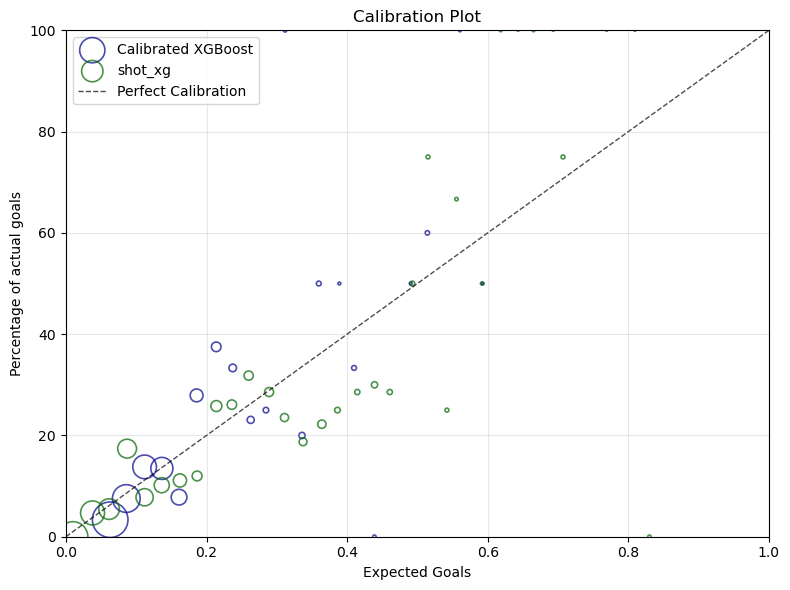

/var/folders/lq/f37yc48d27g7r98zwsmqf41w0000gn/T/ipykernel_1956/904565022.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xgb_hist = df_eval.groupby('xgb_xg_bin').agg(


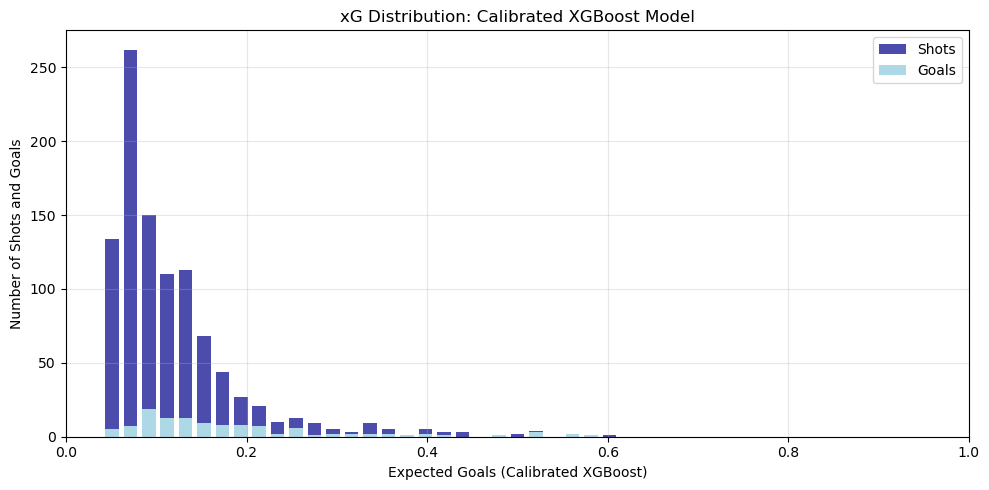

/var/folders/lq/f37yc48d27g7r98zwsmqf41w0000gn/T/ipykernel_1956/904565022.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shot_xg_hist = df_eval.groupby('shot_xg_bin').agg(


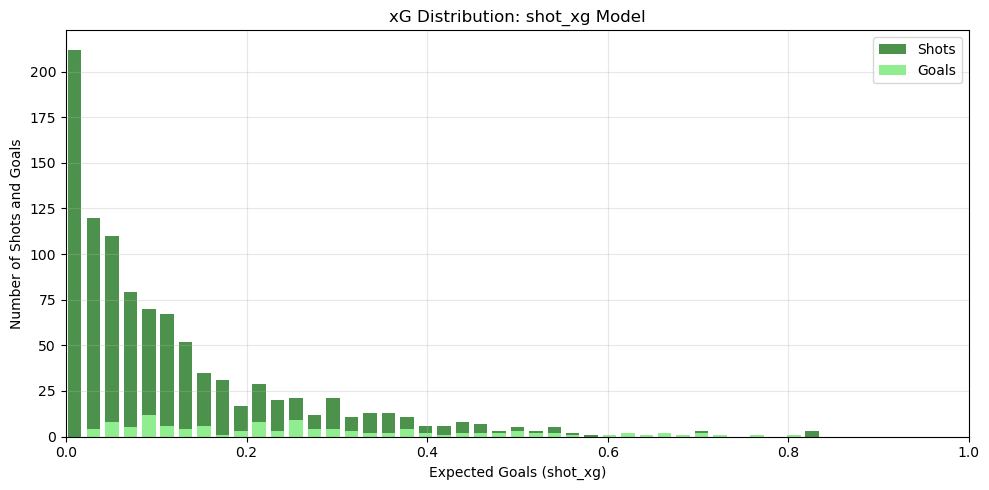

In [8]:
# Driblab-Style Calibration and Distribution Plots
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for both models
df_eval = pd.DataFrame({
    'xgboost_xg': sigmoid_preds_proba,  # Use calibrated XGBoost
    'shot_xg': df.loc[X_test.index, 'shot_xg'].values,
    'is_goal': y_test.values
})

def create_calibration_data(df, xg_column, goal_column, bins=40):
    """Create calibration data for scatter plot"""
    df = df.copy()
    bin_edges = np.linspace(0, 1, bins + 1)
    df['xg_bin'] = pd.cut(df[xg_column], bins=bin_edges, include_lowest=True)
    
    grouped = df.groupby('xg_bin').agg(
        avg_xg=(xg_column, 'mean'),
        goal_rate=(goal_column, 'mean'),
        count=(goal_column, 'count')
    ).dropna()
    
    # Filter bins with at least some shots
    grouped = grouped[grouped['count'] > 0]
    return grouped

def plot_calibration_scatter(grouped, label, color, ax):
    """Plot calibration scatter with bubble sizes"""
    sizes = grouped['count'] * 2  # Adjust scaling as needed
    ax.scatter(
        grouped['avg_xg'],
        grouped['goal_rate'] * 100,
        s=sizes,
        facecolors='none',
        edgecolors=color,
        linewidths=1.2,
        alpha=0.7,
        label=label
    )

# Create calibration data
xgb_cal_data = create_calibration_data(df_eval, 'xgboost_xg', 'is_goal')
shot_xg_cal_data = create_calibration_data(df_eval, 'shot_xg', 'is_goal')

# Plot 1: Calibration Plot (scatter)
plt.figure(figsize=(8, 6))
ax1 = plt.gca()

plot_calibration_scatter(xgb_cal_data, 'Calibrated XGBoost', 'darkblue', ax1)
plot_calibration_scatter(shot_xg_cal_data, 'shot_xg', 'darkgreen', ax1)

# Perfect calibration line
plt.plot([0, 1], [0, 100], 'k--', linewidth=1, alpha=0.7, label='Perfect Calibration')

plt.xlabel('Expected Goals')
plt.ylabel('Percentage of actual goals')
plt.title('Calibration Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Plot 2: Distribution Plot (histogram)
bins = np.linspace(0, 1, 50)

# XGBoost distribution
df_eval['xgb_xg_bin'] = pd.cut(df_eval['xgboost_xg'], bins=bins, include_lowest=True)
xgb_hist = df_eval.groupby('xgb_xg_bin').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
)
xgb_bin_centers = [interval.mid for interval in xgb_hist.index if pd.notna(interval)]
xgb_shots = xgb_hist['shots'].values
xgb_goals = xgb_hist['goals'].values

plt.figure(figsize=(10, 5))
plt.bar(xgb_bin_centers, xgb_shots, width=0.015, label='Shots', color='darkblue', alpha=0.7)
plt.bar(xgb_bin_centers, xgb_goals, width=0.015, label='Goals', color='lightblue')
plt.xlabel('Expected Goals (Calibrated XGBoost)')
plt.ylabel('Number of Shots and Goals')
plt.title('xG Distribution: Calibrated XGBoost Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# shot_xg distribution
df_eval['shot_xg_bin'] = pd.cut(df_eval['shot_xg'], bins=bins, include_lowest=True)
shot_xg_hist = df_eval.groupby('shot_xg_bin').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
)
shot_xg_bin_centers = [interval.mid for interval in shot_xg_hist.index if pd.notna(interval)]
shot_xg_shots = shot_xg_hist['shots'].values
shot_xg_goals = shot_xg_hist['goals'].values

plt.figure(figsize=(10, 5))
plt.bar(shot_xg_bin_centers, shot_xg_shots, width=0.015, label='Shots', color='darkgreen', alpha=0.7)
plt.bar(shot_xg_bin_centers, shot_xg_goals, width=0.015, label='Goals', color='lightgreen')
plt.xlabel('Expected Goals (shot_xg)')
plt.ylabel('Number of Shots and Goals')
plt.title('xG Distribution: shot_xg Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [9]:
# Save both XGBoost models in .pkl format
import pickle

# Save original XGBoost model
with open('xgboost_original.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save calibrated XGBoost model
with open('xgboost_calibrated.pkl', 'wb') as f:
    pickle.dump(cal_clf_sigmoid, f)

print("Both models saved successfully!")
print("Files created:")
print("- xgboost_original.pkl")
print("- xgboost_calibrated.pkl")

Both models saved successfully!
Files created:
- xgboost_original.pkl
- xgboost_calibrated.pkl
